<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/generate_figure3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating Figure 3...
C60  : min=6.302, p95=70.120, p99=160.153, max=6496.483
C700 : min=1.631, p95=21.425, p99=49.910, max=2203.549
Saved: /content/figure3_clearer.png


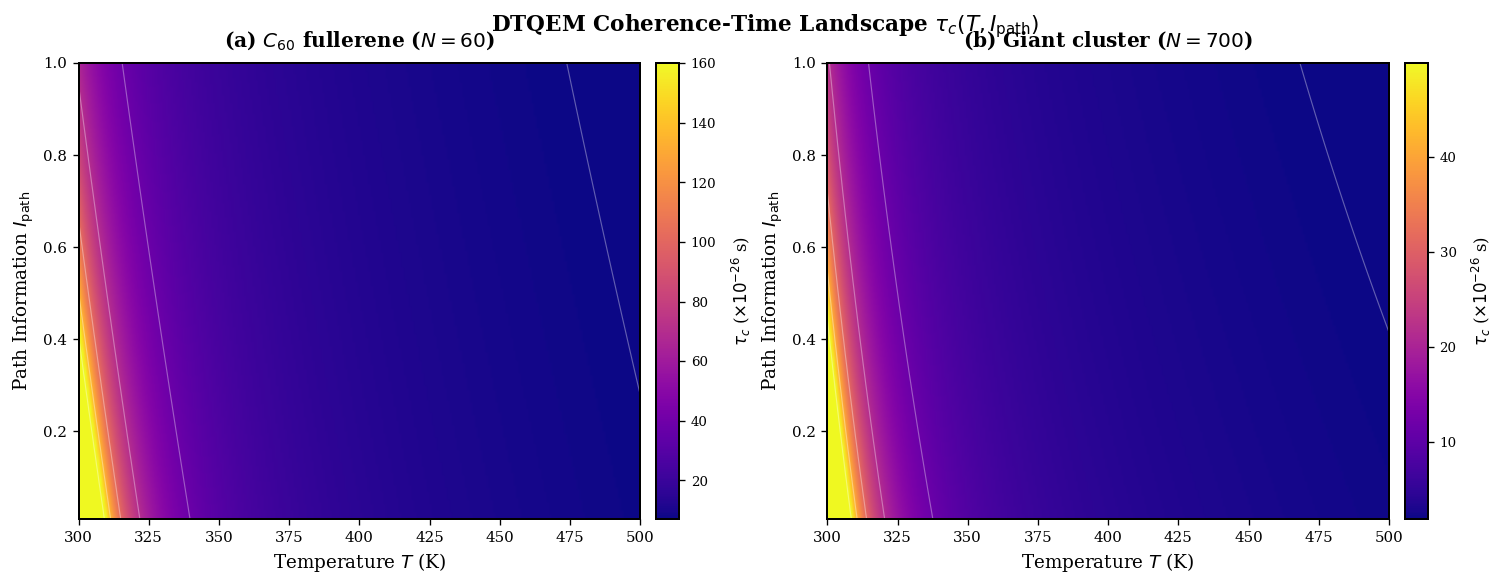

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DTQEM Figure 3 - clearer corrected version
Key fix: use independent percentile-based color scaling for each panel
instead of a single shared global scale that makes both panels look blue.
"""

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

try:
    get_ipython  # type: ignore[name-defined]
    matplotlib.use('inline')
except Exception:
    matplotlib.use('Agg')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.linewidth': 1.2,
    'figure.dpi': 120,
})

C_LIGHT = 299792458.0
M_U     = 1.660539e-27
T_REF   = 300.0

tau_c0  = 9.8e-26
beta    = 0.44
delta   = 0.33
zeta    = 0.005
A       = 1.0
B       = 1.5
C_joint = 0.8
v       = 150.0


def calculate_tau_c(m_kg, N_atoms, I_path, T_kelvin):
    m_s = m_kg / M_U
    v_s = v / C_LIGHT
    dT = np.maximum(1e-6, (T_kelvin - T_REF) / T_REF)
    I_safe = np.maximum(I_path, 1e-3)

    kinetic = A * (m_s ** beta) * (v_s ** delta) * I_safe
    thermal = B * (1.0 + zeta * N_atoms) * dT
    joint = C_joint * (m_s ** beta) * (v_s ** delta) * I_safe * (1.0 + zeta * N_atoms) * dT

    denom = np.maximum(kinetic + thermal + joint, 1e-35)
    return tau_c0 / denom


def generate_figure3(output_path="figure3_clearer.png", show=True):
    print("Generating Figure 3...")

    m_C60  = 720  * M_U
    N_C60  = 60
    m_C700 = 8400 * M_U
    N_C700 = 700

    T_vals = np.linspace(300.0, 500.0, 220)
    I_vals = np.linspace(0.01, 1.0, 220)
    T_grid, I_grid = np.meshgrid(T_vals, I_vals)

    tau60  = calculate_tau_c(m_C60,  N_C60,  I_grid, T_grid) * 1e26
    tau700 = calculate_tau_c(m_C700, N_C700, I_grid, T_grid) * 1e26

    print(f"C60  : min={tau60.min():.3f}, p95={np.percentile(tau60,95):.3f}, p99={np.percentile(tau60,99):.3f}, max={tau60.max():.3f}")
    print(f"C700 : min={tau700.min():.3f}, p95={np.percentile(tau700,95):.3f}, p99={np.percentile(tau700,99):.3f}, max={tau700.max():.3f}")

    fig = plt.figure(figsize=(13, 5))
    ax1 = fig.add_axes([0.06, 0.12, 0.36, 0.76])
    ax2 = fig.add_axes([0.54, 0.12, 0.36, 0.76])
    cax1 = fig.add_axes([0.43, 0.12, 0.015, 0.76])
    cax2 = fig.add_axes([0.91, 0.12, 0.015, 0.76])

    panels = [
        (ax1, cax1, tau60,  r'(a) $C_{60}$ fullerene ($N=60$)'),
        (ax2, cax2, tau700, r'(b) Giant cluster ($N=700$)'),
    ]

    for ax, cax, data, title in panels:
        vmin = np.percentile(data, 5)
        vmax = np.percentile(data, 99)
        im = ax.imshow(
            data,
            extent=[300, 500, 0.01, 1.0],
            origin='lower',
            aspect='auto',
            cmap='plasma',
            vmin=vmin,
            vmax=vmax,
            interpolation='bilinear'
        )
        levels = np.linspace(vmin, vmax, 6)
        ax.contour(T_vals, I_vals, data, levels=levels, colors='white', alpha=0.35, linewidths=0.7)
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel(r'Temperature $T$ (K)', fontsize=11)
        ax.set_ylabel(r'Path Information $I_{\mathrm{path}}$', fontsize=11)
        ax.tick_params(labelsize=9)
        cb = fig.colorbar(im, cax=cax, orientation='vertical')
        cb.set_label(r'$\tau_c$ ($\times 10^{-26}$ s)', fontsize=10, labelpad=8)
        cb.ax.tick_params(labelsize=8)

    fig.text(0.5, 0.965, r'DTQEM Coherence-Time Landscape $\tau_c(T, I_{\mathrm{path}})$',
             ha='center', va='top', fontsize=13, fontweight='bold')

    out = Path(output_path)
    fig.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved: {out.resolve()}")
    if show:
        plt.show()
    plt.close(fig)
    return str(out.resolve())


if __name__ == '__main__':
    generate_figure3('figure3_clearer.png', show=True)